# MNIST Classification

## Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## Load MNIST Data

In [2]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# print("[train_data]")
print("Type : {}".format(type(train_data)))
print("Shape : {}".format(train_data.shape))

# print("[test_data]")
print("Type : {}".format(type(test_data)))
print("Shape : {}".format(test_data.shape))

# print("[train_labels]")
print("Type : {}".format(type(train_labels)))
print("Shape : {}".format(train_labels.shape))

# print("[test_labels]")
print("Type : {}".format(type(test_labels)))
print("Shape : {}".format(test_labels.shape))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Type : <class 'numpy.ndarray'>
Shape : (60000, 28, 28)
Type : <class 'numpy.ndarray'>
Shape : (10000, 28, 28)
Type : <class 'numpy.ndarray'>
Shape : (60000,)
Type : <class 'numpy.ndarray'>
Shape : (10000,)


## Show Train/Test data, labels

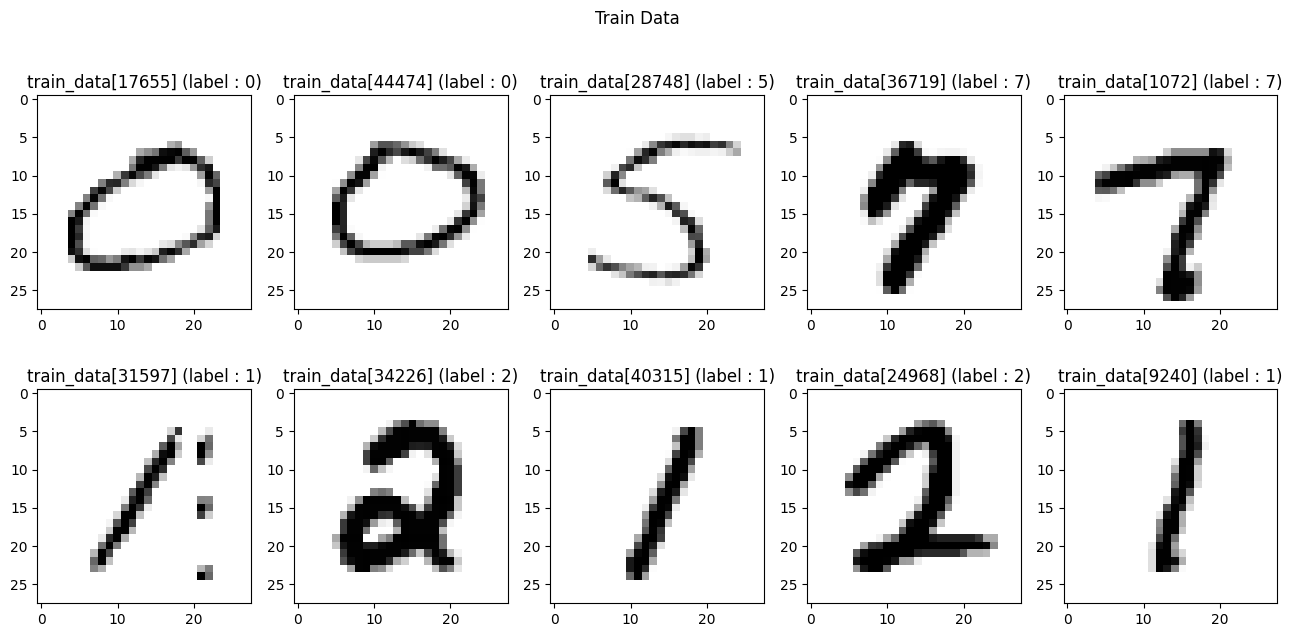

In [3]:
idx_show = np.arange(0, train_data.shape[0])
np.random.shuffle(idx_show)
idx_show = idx_show[0:10]
fig_train, ax_train = plt.subplots(2,5,figsize=(16, 7))
fig_train.suptitle("Train Data")
for idx in range(10):
    ax_train[idx//5, idx%5].imshow(train_data[idx_show[idx]],cmap="binary")
    ax_train[idx//5, idx%5].set_title("train_data[{}] (label : {})".format(idx_show[idx], train_labels[idx_show[idx]]))

## Min Max Scaler

In [4]:
train_data, test_data = train_data / 255.0, test_data / 255.0

## Model 정의

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    # tf.keras.layers.Dense(256, activation='sigmoid'),
    # tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

## Model compile

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 학습 (Training)

In [7]:
history = model.fit(train_data, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8104 - loss: 0.7261
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9149 - loss: 0.3078
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9219 - loss: 0.2794
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9235 - loss: 0.2741
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9254 - loss: 0.2663


## Training 결과 Test

In [8]:
%%time
model.evaluate(test_data,  test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9127 - loss: 0.3066
CPU times: user 929 ms, sys: 56.9 ms, total: 986 ms
Wall time: 873 ms


[0.269209623336792, 0.923799991607666]